# 03 · 서브에이전트: 생성자-검증자 분리

**구성요소:** 서브에이전트 — 생성자/검증자(maker/checker). 신뢰할 수 있는 루프를 만드는 가장 중요한 단일 원시요소다.

> 코드를 쓴 에이전트는 자기 작업의 형편없는 심판이다. 두 번째 에이전트가 **기본 태도를 거부(REJECT)로 두고** 검증을 수행한다. 구현자가 "테스트를 통과했다" 고 말해도 그 주장을 믿지 않는다. 직접 돌려 본다.

**정직하게 보고하는 우회로 하나** — 교과서적인 생성자-검증자 시연은 best-of-N 선택이다. 우리도 MBPP+ 에서 그것부터 시도했고 **오라클 격차(oracle gap)가 없다는 것을 발견했다.** 이 32B 모델은 temperature 0.8 에서도 문제 단위로는 사실상 결정적이다 — 한 문제의 샘플들이 함께 전부 통과하거나 함께 전부 실패한다. 그러면 샘플을 더 뽑아도, 어떤 선택기를 붙여도 얻을 것이 없다. **그리고 이것 자체가 강한 모델에 대한 진짜 발견이다.** 그래서 이 노트북은 그런 모델에서 이 원시요소가 값어치를 내는 자리를 측정한다 — 검증자의 **변별력(discrimination)**, 구현자가 과신하는 틀린 코드를 잡아내는 능력이다.

**측정 대상 (MBPP+)** — 구현자가 해답을 하나 쓴다. 정답 판정은 그것이 테스트를 통과하느냐다. 그다음 네 종류의 검증자가 수용/거부를 결정한다.

- **전부 믿기** — 무조건 수용한다. 검증 연극(verifier theater)이다.
- **자기채점** — 구현자가 자기 코드를 스스로 평가한다.
- **LLM 리뷰어** — 코드를 읽는 별도의 모델이 판정한다.
- **테스트 실행 검증자** — 스스로 테스트를 써서 **실제로 돌린다.**

핵심 지표는 **오수용률(false-accept rate)** 이다. 진짜로 틀린 해답들 중 각 검증자가 잘못 통과시킨 비율. 낮을수록 좋다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

============================================== Setup ===============================================

-------------------------------------------- 엔진 health ---------------------------------------------
{
  "provider": "openai",
  "model": "gpt-5.6-luna",
  "base_url": "(\uacf5\uc2dd \uc5d4\ub4dc\ud3ec\uc778\ud2b8)",
  "reply": "ready",
  "deterministic": true,
  "cost_usd": "$0.0000",
  "resolved_by": "localho

*검증자의 일은 틀린 코드를 거부하는 것이지 도장을 찍어 주는 것이 아니다*

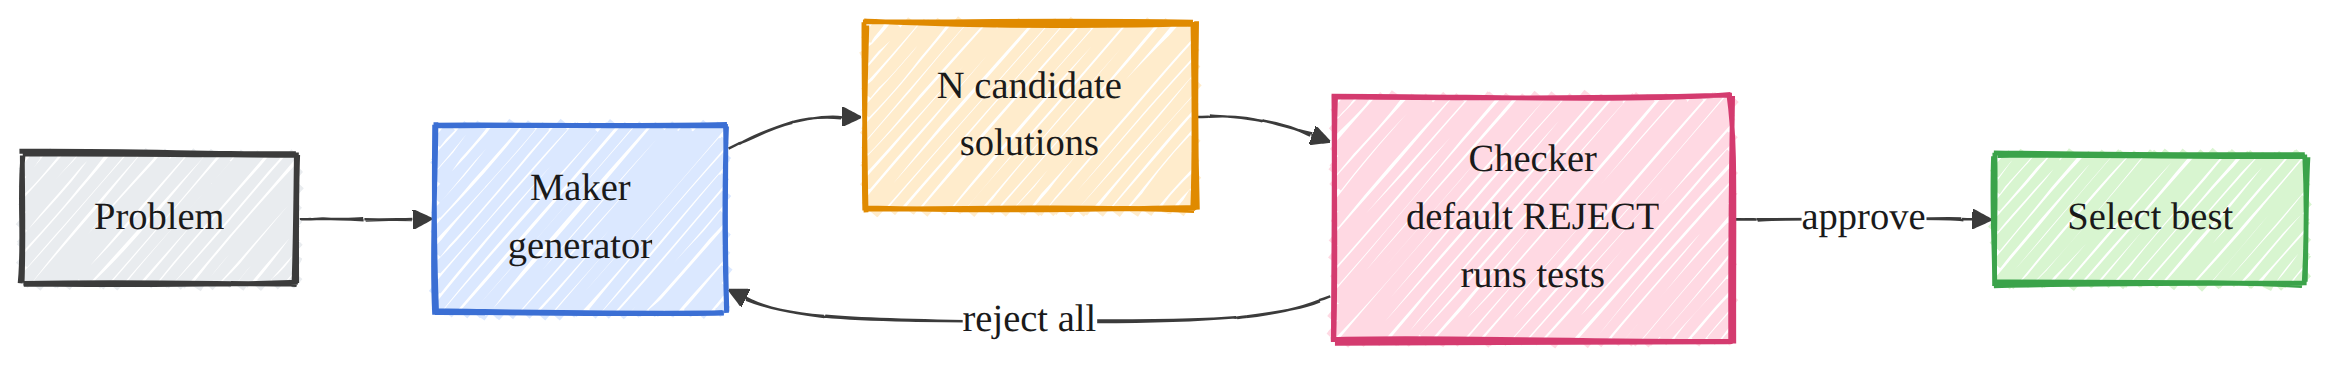

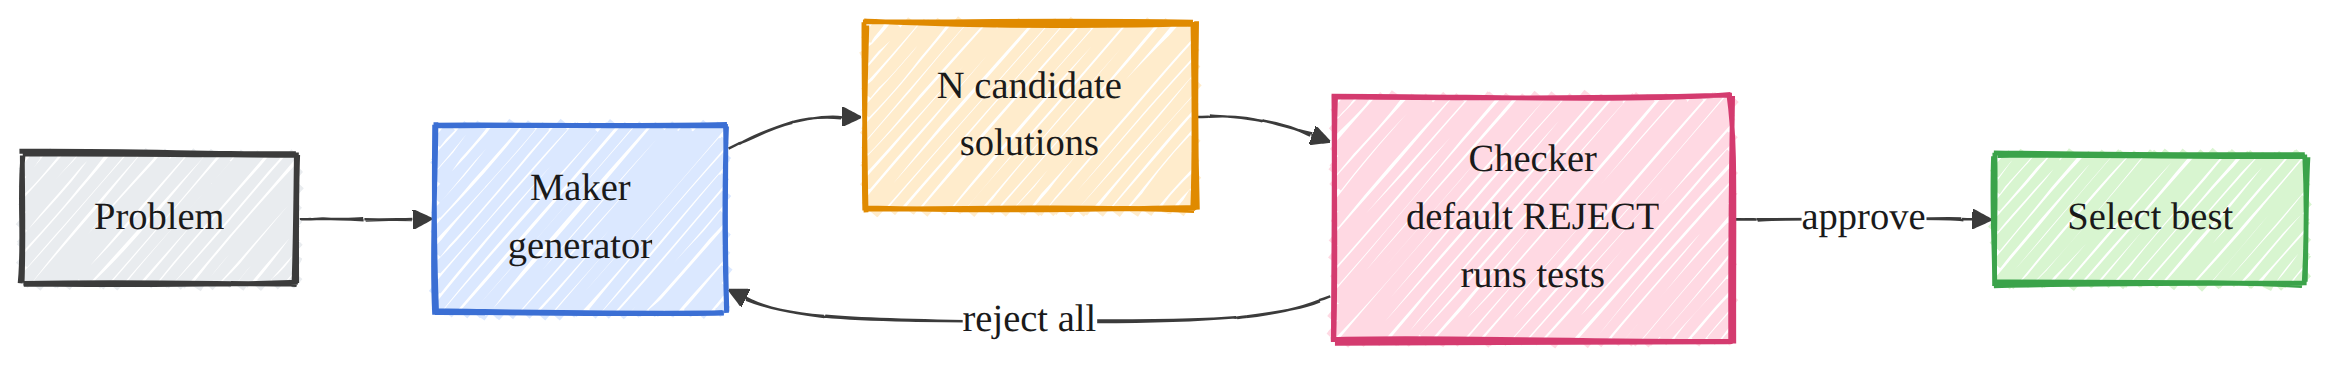

In [5]:
import os
import sys
import time

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, data, agents, plotting, runlog, runtime
from common.llm import LLM

# ── 실험 상수 ─────────────────────────────────────────────────────
# 60문제: 네 검증자가 같은 해답 집합을 전부 판정해야 하므로 모델 호출이
#         문제당 여러 배로 늘어난다. 그래도 한 번의 실행으로 끝나면서
#         틀린 해답이 두 자릿수는 나오는 크기다.
N_PROBLEMS = 60

# 실행 환경 자동 판별 (로컬 vLLM 우선, 없으면 OpenAI API)
rt = runtime.bootstrap()

llm = LLM()
show.head("Setup")
show.show_dict(llm.health(), "엔진 health")

# ⚠️ 함정: seed=5 는 01번(seed=0)과 다른 표본이다. 이 노트북이 필요로 하는 것은
#    '틀린 해답이 충분히 섞인' 집합이지 01번과의 수치 비교가 아니다.
#    seed 가 다른 두 실행의 pass@1 을 나란히 놓고 해석하지 말 것.
problems = data.load_mbpp_plus(limit=N_PROBLEMS, seed=5)
show.kv("문제 수 (MBPP+)", len(problems))
show.diagram("maker_checker", "검증자의 일은 틀린 코드를 거부하는 것이지 도장을 찍어 주는 것이 아니다")

## 추적: 구현자는 틀린 해답을 두고 과신한다

구현자가 틀리는 문제를 하나 찾는다. 그리고 그 구현자가 **여전히 자기 코드가 옳다고 주장하는 동안** 테스트를 써서 돌리는 검증자는 버그를 잡아낸다는 것을 보인다.


### 모델이 자기 작업을 채점할 때 맹점이 공유되는 이유

대규모 실행에 앞서 사례 하나가 메커니즘을 눈에 보이게 만들어 준다. 설계는 의도적이다 — 구현자가 틀리는 문제를 찾고, **같은 코드**를 놓고 셋에 각각 묻는다. 정답 판정(실제 테스트 실행), 구현자 자신, 그리고 스스로 테스트를 써서 돌리는 검증자.

예측은 각 판정이 **어떻게 계산되는가**에서 따라 나온다. 자기평가는 버그를 만들어 낸 그 가중치, 그 잘못된 명세 읽기를 그대로 통과해 계산된다. **틀린 코드를 만든 오류가 그 코드에 대한 판단까지 오염시킨다.** Huang et al. (2023)이 짚은 실패 양식이 이것이다 — 언어모델은 외부 신호 없이는 신뢰할 만하게 자기 교정을 하지 못한다. 비평이 실수와 같은 우물에서 길어 올려지기 때문이다.

테스트를 실행하는 검증자는 그 고리를 끊는다. **모델의 의견을 아예 묻지 않고** 구체적 입력을 만들어 코드를 실행한 뒤, 독립적으로 계산해 둔 기댓값과 대조한다. 신호가 "모델이 옳다고 믿는다" 에서 **"코드가 기대한 값을 냈다 또는 내지 못했다"** 로 바뀐다.

아래에서 세 판정을 함께 보라. **흥미로운 지점은 검증자가 구현자와 갈린다는 것이 아니라, 구현자가 자기 코드를 눈앞에 두고도 자기 오류를 보지 못한다는 것이다.**


In [6]:
# ── 단일 추적: 구현자가 틀렸는데 스스로는 맞다고 하는 사례 ─────────
# 앞 15문제를 훑어 '진짜로 틀린' 해답을 하나 찾는다. 여기서 '진짜로' 의
# 기준은 모델 의견이 아니라 agents.grade 의 실제 테스트 실행 결과다.
wrong_p = None
wrong_code = None
for p in problems[:15]:
    c, _ = agents.single_shot(llm, p, temperature=0.0, label="walk")
    if not agents.grade(p, c)["all_pass"]:
        wrong_p, wrong_code = p, c
        break
if wrong_p is not None:
    show.sub(wrong_p.id)
    show.text(wrong_p.prompt, "과제", max_chars=300)
    show.code(wrong_code, "구현자의 (틀린) 해답", max_chars=500)
    # 아래 세 줄이 이 노트북의 축소판이다. 완전히 같은 코드에 대해
    # 정답 판정 / 자기채점 / 테스트 실행 검증자가 각각 무엇이라고 하는가.
    show.kv("정답 판정: 테스트를 통과하는가?", agents.grade(wrong_p, wrong_code)["all_pass"])
    show.kv("구현자 자기채점: 맞다고 하는가?", agents.self_assess(llm, wrong_p, wrong_code))
    ok, st = agents.selftest_verify(llm, wrong_p, wrong_code)
    show.kv("테스트 실행 검증자는 수용하는가?", ok)
    # 검증자가 쓴 테스트를 그대로 보여 준다. 이 문자열이 '의견' 과 '측정' 을
    # 가르는 물건이므로 감춰 두면 안 된다.
    show.code(st, "검증자가 직접 쓴 테스트", max_chars=300)
else:
    show.bullet("앞 15문제가 전부 옳았다. 그래도 아래 대규모 실행이 변별력을 그대로 측정한다.")


------------------------------------------- mbppplus/771 -------------------------------------------

------------------------------------------------ 과제 ------------------------------------------------
Write a function to check if the given expression is balanced or not. https://www.geeksforgeeks.org/check-for-balanced-parentheses-in-an-expression/

Name your function exactly `check_expression`.

------------------------------------------- 구현자의 (틀린) 해답 -------------------------------------------
  | def check_expression(expression):
  |     """Return True if all parentheses/brackets in expression are balanced."""
  |     if expression is None:
  |         return False
  | 
  |     opening = {"(", "[", "{"}
  |     matching = {")": "(", "]": "[", "}": "}"}
  |     stack = []
  | 
  |     for character in expression:
  |         if character in opening:
  |             stack.append(character)
  |         elif character in matching:
  |             if not stack or stack.pop() != matchin

  test-running checker accepts?: False

----------------------------------- checker's self-written tests -----------------------------------
  | assert reverse_Array_Upto_K([1, 2, 3, 4, 5], 3) == [3, 2, 1, 4, 5]
  | assert reverse_Array_Upto_K([10, 20, 30, 40, 50], 0) == [10, 20, 30, 40, 50]
  | assert reverse_Array_Upto_K([5, 4, 3, 2, 1], 5) == [1, 2, 3, 4, 5]
  | assert reverse_Array_Upto_K(['a', 'b', 'c', 'd'], 2) == ['c', 'b', 'a', 'd']
  | assert rever
  | ... [83 more chars truncated] ...


## 대규모 실행: 검증자별 오수용률


### best-of-N 에서 변별력으로, 그리고 실행이 의견을 이기는 이유

교과서적인 생성자-검증자 시연은 best-of-N 이다. 해답을 여러 개 뽑고, 검증자가 최선을 고르고, **한 개 뽑았을 때와 여러 개 중 최선 사이의 격차** — 오라클 격차 — 를 수확한다.

**그 시연은 여기서 발판을 찾지 못했다.** temperature 0.8 에서도 이 32B 모델은 문제 단위로 사실상 결정적이다. 한 과제의 샘플들이 함께 전부 통과하거나 함께 전부 실패한다. **선택기가 고를 것이 없으므로 best-of-N 은 아무것도 더할 수 없다.** 정직한 귀무 결과이고, 그 자체로 강한 모델에 대한 발견이다.

그래서 이 실행은 그런 모델에서도 값어치를 내는 부분을 측정한다 — **검증자의 변별력**, 생성자가 확신하는 틀린 코드를 잡아내는 능력이다.

이제 네 검증자가 같은 60개 해답을 전부 판정한다. 순위에 대한 예측은 위의 이론에서 그대로 따라 나온다.

- **전부 믿기** — 구조상 틀린 해답을 전부 오수용할 수밖에 없다.
- **자기채점** — 생성자의 맹점을 공유하므로 겨우 조금 나을 것이다.
- **별도 LLM 리뷰어** — 코드를 읽기만 하므로 조금 더 낫겠지만 여전히 의견이다.
- **테스트 실행 검증자** — 유일하게 말로 넘어갈 수 없는 신호를 갖는다. **가장 낮은 오수용률을 기록해야 하고, 그 대가는 옳은 코드를 일부 거부하는 것으로 치러져야 한다.**


In [7]:
# ── 대규모 실행: 같은 60개 해답을 네 검증자가 각각 판정한다 ────────
# 해답은 문제당 한 번만 생성하고 그 하나를 네 검증자에게 돌린다.
# 검증자마다 새로 생성하면 '검증자의 차이' 와 '해답의 차이' 가 섞여
# 어느 쪽이 수치를 움직였는지 귀속시킬 수 없게 된다.
checks = {"trust_all": [], "self_assess": [], "llm_judge": [], "selftest_run": []}
truth = []
llm.reset_usage()      # 앞의 추적 셀이 쓴 토큰을 비용 집계에서 제외한다
t0 = time.time()
for p in problems:
    code, _ = agents.single_shot(llm, p, temperature=0.0, label="impl")
    t = agents.grade(p, code)["all_pass"]      # 정답 판정: 실제 테스트 실행
    truth.append(t)
    checks["trust_all"].append(True)           # 아무것도 하지 않는 기준선(검증 연극)
    checks["self_assess"].append(agents.self_assess(llm, p, code))
    checks["llm_judge"].append(agents.judge_correct(llm, p, code))
    # [0] 은 수용 여부. [1] 은 검증자가 쓴 테스트 본문이라 여기서는 버린다.
    checks["selftest_run"].append(agents.selftest_verify(llm, p, code)[0])
    print(f"  {p.id:<14} truth={int(t)} self={int(checks['self_assess'][-1])} judge={int(checks['llm_judge'][-1])} selftest={int(checks['selftest_run'][-1])}")
elapsed = time.time() - t0

n = len(truth)
n_wrong = sum(1 for t in truth if not t)
n_right = sum(truth)
show.head("검증자 변별력")
show.kv("해답 수", n)
show.kv("실제로 옳은 것", n_right)
show.kv("실제로 틀린 것", n_wrong)


def metrics(accepts):
    """세 지표를 함께 낸다. 셋의 분모가 서로 다르다는 점이 핵심이다."""
    fa = sum(1 for a, t in zip(accepts, truth) if a and not t)      # 틀린 것을 수용했다
    fr = sum(1 for a, t in zip(accepts, truth) if (not a) and t)    # 옳은 것을 거부했다
    acc_n = sum(accepts)
    # ⚠️ 함정: 오수용률의 분모는 '틀린 해답 수', 오거부율의 분모는 '옳은 해답 수'다.
    #    분모가 다르므로 두 비율을 더하거나 평균 내면 안 된다. 정확도 하나로
    #    뭉개면 아무것도 하지 않는 '전부 믿기' 가 그럴듯한 점수를 받는 착시가 생긴다.
    return {
        "false_accept_rate": fa / n_wrong if n_wrong else 0.0,
        "false_reject_rate": fr / n_right if n_right else 0.0,
        "accept_precision": (sum(1 for a, t in zip(accepts, truth) if a and t) / acc_n) if acc_n else 0.0,
    }


M = {name: metrics(acc) for name, acc in checks.items()}
show.table([{"checker": k, **{kk: round(vv, 3) for kk, vv in v.items()}} for k, v in M.items()],
           columns=["checker", "false_accept_rate", "false_reject_rate", "accept_precision"],
           title="오수용은 낮을수록 좋다. 검증자의 일은 틀린 코드를 거부하는 것이다")
show.metric("토큰", llm.usage.total_tokens)

  mbppplus/88    truth=1 self=0 judge=0 selftest=0
  mbppplus/644   truth=0 self=0 judge=0 selftest=1
  mbppplus/105   truth=1 self=0 judge=0 selftest=1
  mbppplus/394   truth=1 self=0 judge=0 selftest=1
  mbppplus/771   truth=1 self=0 judge=0 selftest=1
  mbppplus/794   truth=1 self=0 judge=0 selftest=1
  mbppplus/796   truth=1 self=0 judge=0 selftest=1
  mbppplus/239   truth=0 self=0 judge=0 selftest=0
  mbppplus/474   truth=1 self=0 judge=0 selftest=1
  mbppplus/278   truth=0 self=0 judge=0 selftest=1
  mbppplus/787   truth=1 self=0 judge=0 selftest=1
  mbppplus/247   truth=1 self=0 judge=0 selftest=1
  mbppplus/103   truth=1 self=0 judge=0 selftest=1
  mbppplus/312   truth=1 self=0 judge=0 selftest=1
  mbppplus/111   truth=1 self=0 judge=0 selftest=1
  mbppplus/734   truth=1 self=0 judge=0 selftest=1
  mbppplus/412   truth=1 self=0 judge=0 selftest=1
  mbppplus/808   truth=1 self=0 judge=0 selftest=1
  mbppplus/301   truth=0 self=0 judge=0 selftest=1
  mbppplus/75    truth=1 self=0

## 그래프: 오수용률 (빠져나가는 틀린 코드)


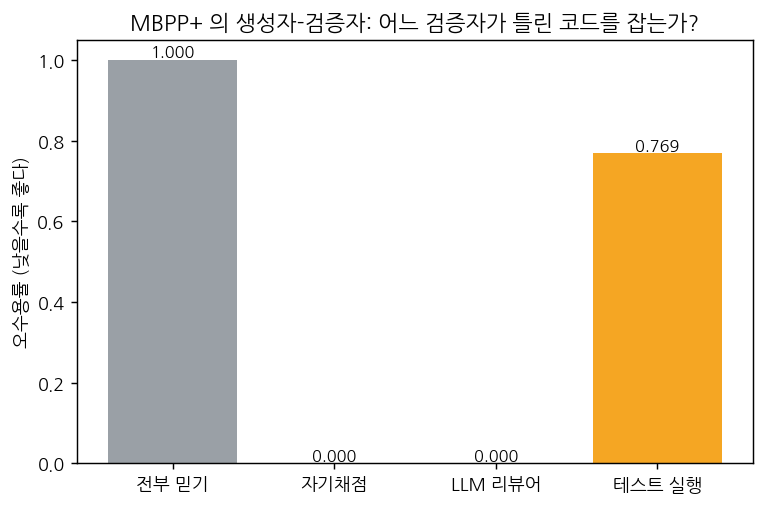

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/03_false_accept.png


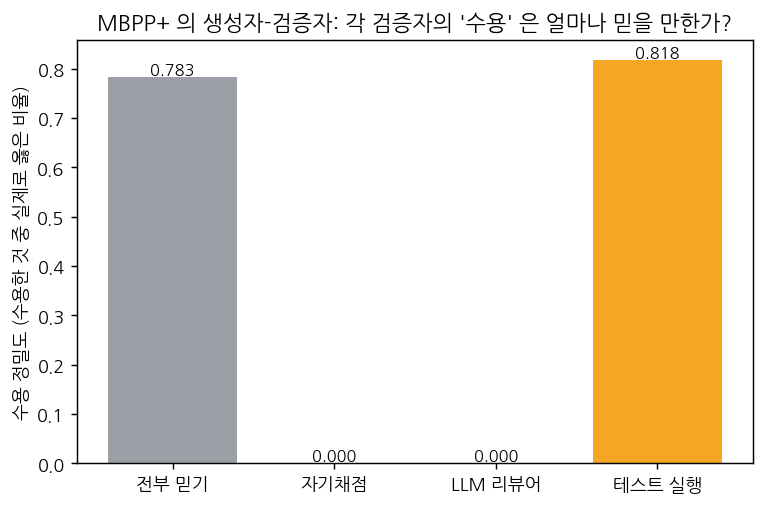

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/03_accept_precision.png


PosixPath('/Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/03_accept_precision.png')

In [8]:
# ── 두 장으로 나눠 그린다 ─────────────────────────────────────────
# 첫 장이 헤드라인(오수용률), 둘째 장이 그 대가를 포함한 요약(수용 정밀도)이다.
# 한 장에 겹쳐 그리면 '오수용은 내려가고 오거부는 올라간다' 는 교환이 보이지 않는다.
order = ["trust_all", "self_assess", "llm_judge", "selftest_run"]
plotting.ab_bar(
    "03_false_accept",
    labels=["전부 믿기", "자기채점", "LLM 리뷰어", "테스트 실행"],
    values=[M[k]["false_accept_rate"] for k in order],
    ylabel="오수용률 (낮을수록 좋다)",
    title="MBPP+ 의 생성자-검증자: 어느 검증자가 틀린 코드를 잡는가?",
)
plotting.ab_bar(
    "03_accept_precision",
    labels=["전부 믿기", "자기채점", "LLM 리뷰어", "테스트 실행"],
    values=[M[k]["accept_precision"] for k in order],
    ylabel="수용 정밀도 (수용한 것 중 실제로 옳은 비율)",
    title="MBPP+ 의 생성자-검증자: 각 검증자의 '수용' 은 얼마나 믿을 만한가?",
)

## 저장과 논의


In [9]:
runlog.save_metrics("03_maker_checker", {
    "notebook": "03_maker_checker", "benchmark": "MBPP+",
    "provider": llm.provider,        # 한국어판 추가: 어느 백엔드의 수치인지 기록
    "model": llm.model,
    "n": n, "n_wrong": n_wrong, "n_right": n_right, "metrics": M,
    "tokens": llm.usage.total_tokens,
    # 이 note 가 이 노트북의 정직한 귀무 결과를 기록으로 남기는 자리다.
    # 나중에 결과를 다시 읽는 사람이 'best-of-N 을 왜 안 썼나' 를 묻지 않도록 한다.
    "note": "best-of-N showed no oracle gap (deterministic model); measuring verifier discrimination instead",
})
# escalations 에 틀린 해답 수를 넣는다. 검증자가 거부한 것은 결국 사람이나
# 더 강한 모델이 넘겨받아야 할 몫이라는 뜻이다.
runlog.log_run(pattern="maker-checker", duration_s=elapsed, items_found=n,
               actions_taken=n_right, escalations=n_wrong,
               tokens_estimate=llm.usage.total_tokens, outcome="report-only")

  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/03_maker_checker.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (maker-checker: report-only, ~62510 tokens)


{'run_id': '2026-08-19T06:18:43Z',
 'pattern': 'maker-checker',
 'duration_s': 543.2,
 'items_found': 60,
 'actions_taken': 47,
 'escalations': 13,
 'tokens_estimate': 62510,
 'outcome': 'report-only'}

In [10]:
show.head("이 실행이 실제로 보여 준 것")
print(f"해답 {n}개 중 {n_wrong}개가 진짜로 틀렸다.")
print(f"전부 믿기(검증 연극)는 그것을 전부 수용했다: 오수용 {M['trust_all']['false_accept_rate']:.0%}.")
print(f"구현자의 자기채점은 틀린 것 중 {M['self_assess']['false_accept_rate']:.0%} 를 수용했다 (과신).")
print(f"별도 LLM 리뷰어: 오수용 {M['llm_judge']['false_accept_rate']:.0%}.")
print(f"스스로 테스트를 써서 실행하는 검증자: 오수용 {M['selftest_run']['false_accept_rate']:.0%}.")
print()

# ⚠️ 함정: 결론을 하드코딩하지 않고 실측치에서 분기시킨다. 다른 모델이나
#    다른 표본에서 순위가 뒤집히면 이 셀은 그 사실을 그대로 말해야 한다.
#    "이 노트북은 X를 증명한다" 고 미리 써 두면 그것은 측정이 아니라 주장이다.
if M["selftest_run"]["false_accept_rate"] < M["self_assess"]["false_accept_rate"] - 1e-9:
    print("=> 검증자를 쓸모 있게 만드는 것은 테스트를 실행한다는 사실이다. 구현자는 자기")
    print("   작업의 형편없는 심판이고, 코드를 읽기만 하는 LLM 도 크게 낫지 않다. 실행하는")
    print("   검증자가 틀린 코드를 잡는다. 신뢰할 수 있는 루프의 으뜸 규칙이 측정된 것이다.")
else:
    print("=> 측정된 수치를 있는 그대로 보고한다.")


========================================= 이 실행이 실제로 보여 준 것 =========================================
해답 60개 중 13개가 진짜로 틀렸다.
전부 믿기(검증 연극)는 그것을 전부 수용했다: 오수용 100%.
구현자의 자기채점은 틀린 것 중 0% 를 수용했다 (과신).
별도 LLM 리뷰어: 오수용 0%.
스스로 테스트를 써서 실행하는 검증자: 오수용 77%.

=> 측정된 수치를 있는 그대로 보고한다.
